In [257]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(CURRENT_DIR)
sys.path.append(LIBS_PATH)
print(CURRENT_DIR)

/home/jjavier98/S-noise-gradient


In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import List

# Locals
from utils import *
from dataset import Dataset, SlidingWindowDataset, TensorDataset
from models import *
from dlnr import DLNoiseReduction
from xai_benchmark import XAIBenchmark

In [259]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [260]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

# Functions

In [261]:
# def generate_ts_data(window_size:int, n_var:int, n_samples:int, seed:int=42):
#     """
#     Generate time series data for testing purposes

#     Args:
#         window_size (int): size of the sliding window
#         n_var (int): number of variables
#         n_samples (int): number of samples
#         seed (int, optional): seed for random values. Defaults to 42.

#     Returns:
#         tuple: X and Y dataframes
#     """
#     np.random.seed(seed)

#     # Generar datos con tendencia
#     # trend = np.linspace(0, 1, (window_size, n_var))
#     # seasonal = np.sin(np.linspace(0, 2 * np.pi, (window_size, n_var)))
#     # X = trend + seasonal

#     X = 2 * np.random.rand(window_size, n_var) - 1
#     A = 2 * np.random.rand(1, window_size) - 1

#     X_df = pd.DataFrame(X)
#     A_df = pd.DataFrame(A)

#     for i in range(n_samples):
#         new_X = A_df.values @ X_df.iloc[i:i+window_size].values # + np.random.normal(0, 0.1, (1, n_var))
#         # new_X = np.clip(new_X, -1e10, 1e10)  # Limitar el rango antes de la normalización
#         new_X /= np.linalg.norm(new_X)  # Normalizar
#         new_X = pd.DataFrame(new_X)
#         X_df = pd.concat ([X_df, new_X], axis=0, ignore_index=True)

#     X_df = X_df[window_size:]
#     X_df.reset_index(drop=True, inplace=True)

#     return X_df


def generate_ts_data(window_size:int, n_var:int, n_samples:int, seed:int=42):
    np.random.seed(seed)
    t = np.arange(n_samples)

    # Componentes base
    trend = 0.05 * t
    seasonality = np.sin(2 * np.pi * t / 24)
    # noise = np.random.normal(0, 0.3, size=n_samples)

    # Variables
    target = trend + seasonality
    var1 = 0.05 * (t - 2) + np.sin(2 * np.pi * (t - 2) / 24)  # desfase de 2
    var2 = seasonality
    var3 = trend

    # Crear DataFrame
    df = pd.DataFrame({
        'time': t,
        'y': target,
        'var1': var1,
        'var2': var2,
        'var3': var3
    })
    df = df.set_index('time')
    df = df.astype(np.float32)

    return df


def polinomial_function_multivariable(x:List[float]) -> float:
    """
    Function that takes in two values x0 and x1 and returns its polinomial value.

    Args:
        x (List[float]): list of values.

    Returns:
        float: result of the polinomial function.
    """
    result = 0
    for i, value in enumerate(x):
        result += value**i
    return result


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

# Data generation

In [262]:
df = generate_ts_data(24, 5, 1000)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
y,1000.0,24.981129,14.455678,-0.115926,12.379109,2.509204e+01,37.320437,50.515926
var1,1000.0,24.881578,14.459110,-0.600000,12.281614,2.503301e+01,37.274519,50.515926
var2,1000.0,0.006130,0.706597,-1.000000,-0.707107,6.123234e-17,0.707107,1.000000
var3,1000.0,24.975000,14.440972,0.000000,12.487500,2.497500e+01,37.462501,49.950001


In [264]:
df.to_parquet(os.path.join(DATA_PATH, 'time_series', 'synthetic', 'seno', 'clean.parquet'), index=False)

In [32]:
# X.columns = [f'X{i}' for i in range(5)]

In [33]:
# Y = pd.DataFrame()
# for i in range(len(X)):
#     row = X.iloc[i].values
#     new_y = polinomial_function_multivariable(row)
#     Y = pd.concat([Y, pd.DataFrame([new_y], columns=['Y'])], axis=0)
# Y.reset_index(drop=True, inplace=True)
# Y.describe().T

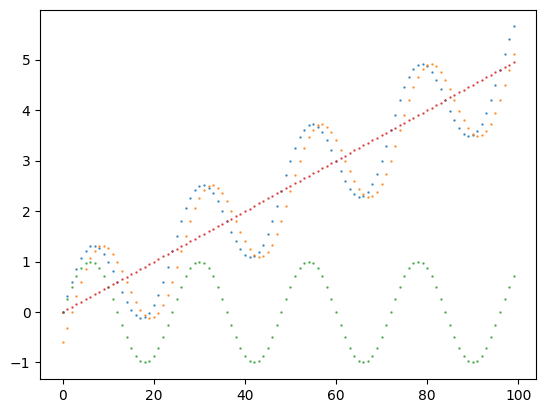

In [37]:
n_show = 100
plt.scatter(range(n_show), df.iloc[:n_show,0], s=0.5, alpha=0.8)
plt.scatter(range(n_show), df.iloc[:n_show,1], s=0.5, alpha=0.8)
plt.scatter(range(n_show), df.iloc[:n_show,2], s=0.5, alpha=0.8)
plt.scatter(range(n_show), df.iloc[:n_show,3], s=0.5, alpha=0.8)

In [ ]:
# df = X.copy()
# df['Y'] = Y.copy()
# df.describe().T

NameError: name 'df' is not defined

## Scale the data between [0,1]

In [39]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
y,1000.0,3.051758e-08,1.0005,-1.737007,-0.872206,7.676075e-03,0.854023,1.767304
var1,1000.0,0.000000e+00,1.0005,-1.763202,-0.871857,1.047852e-02,0.857531,1.773773
var2,1000.0,2.765655e-08,1.0005,-1.424622,-1.009902,-8.679487e-03,0.992543,1.407264
var3,1000.0,0.000000e+00,1.0005,-1.730320,-0.865160,2.642628e-08,0.865160,1.730320


## Show original correlation matrix

<Axes: >

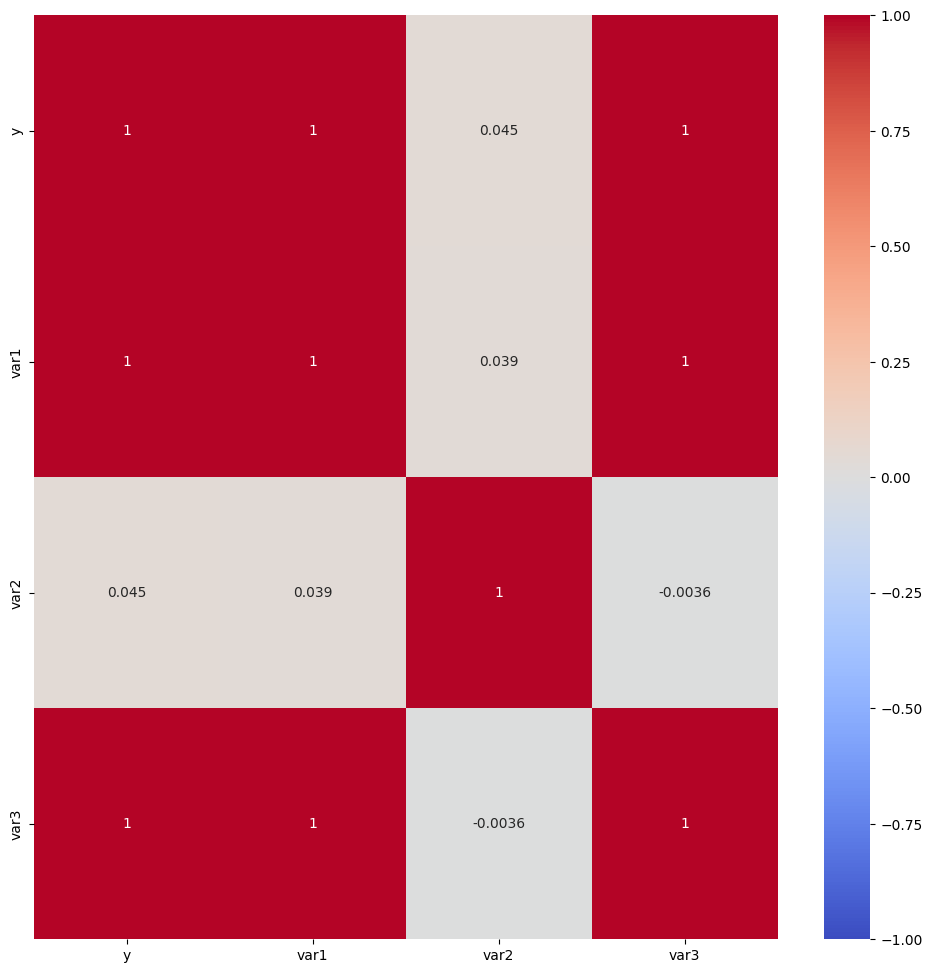

In [40]:
corr_orig = df_scaled.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_orig, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# No noise XAI Benchmarck

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    df_scaled.drop(columns=['y'], inplace=False).values, df_scaled['y'].values, test_size=0.2, shuffle=False
)

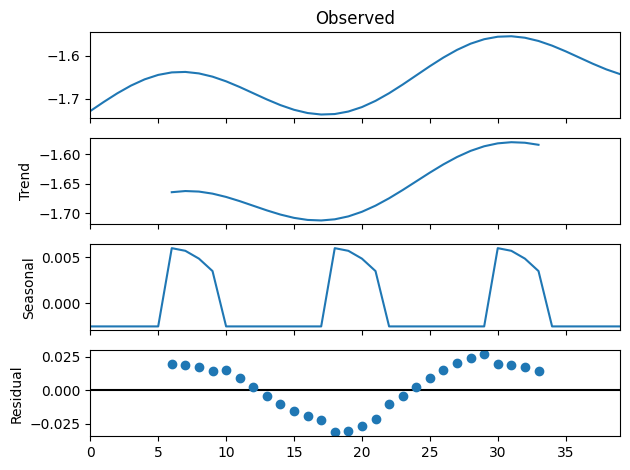

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(y_train[:40], model="additive", period=12)
decomposition.plot()
plt.show()

In [48]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {},
    'knn': {
        "n_neighbors": 5,
        "weights": 'uniform',
        "algorithm": 'auto',
        "leaf_size": 30,
        "p": 2,
        "n_jobs": None
    },
    'arima': {}
    # {
    #     'order': (1, 1, 0),
    #     'seasonal_order': (4, 0, 5, 12)
    # }
}
xai_benchmark = XAIBenchmark(is_ts = True, model_params = model_params)

In [49]:
xai_benchmark.fit(X_train, y_train)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [50]:
predictions, metrics = xai_benchmark.predict(X_test, y_test, get_metrics=True)
metrics

Calculating metrics for ridge model...
Calculating metrics for pls model...
Calculating metrics for decision_tree model...
Calculating metrics for svm model...
Calculating metrics for knn model...
Calculating metrics for arima model...


{'ridge': {'mse': 0.00010035273589892313,
  'rmse': 0.010017621269489236,
  'mae': 0.009005577303469181,
  'mape': 0.006653720512986183,
  'R2': 0.9976729154586792},
 'pls': {'mse': 0.00018868376855929854,
  'rmse': 0.01373622104362399,
  'mae': 0.012365992684915837,
  'mape': 0.009140509613072332,
  'R2': 0.9956246046771163},
 'decision_tree': {'mse': 0.1627596417216221,
  'rmse': 0.4034348047970355,
  'mae': 0.3477063419818878,
  'mape': 0.2340580222851994,
  'R2': -2.774239727034116},
 'svm': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None},
 'knn': {'mse': 0.18901042640209198,
  'rmse': 0.43475329372195903,
  'mae': 0.39116761088371277,
  'mape': 0.26880499720573425,
  'R2': -3.3829703330993652},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}

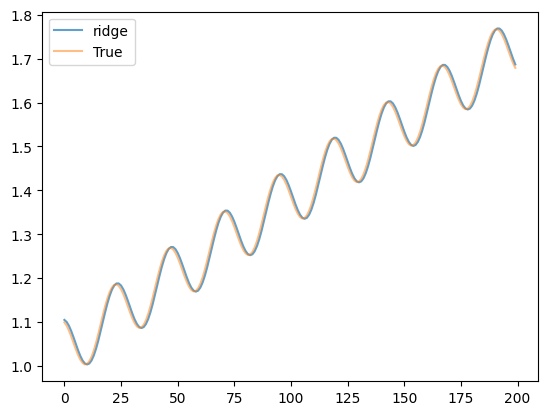

In [51]:
plt.plot(predictions['ridge'], label='ridge', alpha=0.7)
plt.plot(y_test, label='True', alpha=0.5)
plt.legend()

## Add noise

In [164]:
sigma = 0.05
df_noisy = add_gaussian_noise(df_scaled.copy(), df_scaled.columns, mean=0.0, std=sigma)
df_noisy.describe().T

,count,mean,std,min,25%,50%,75%,max
y,1000.0,0.000733,1.004678,-1.780711,-0.856203,0.000918,0.885846,1.816347
var1,1000.0,-0.001204,1.004013,-1.881293,-0.867720,-0.003146,0.865679,1.813678
var2,1000.0,0.001262,1.002903,-1.544185,-0.993885,-0.004017,0.996247,1.536839
var3,1000.0,0.002628,1.002906,-1.768056,-0.859571,-0.010430,0.870647,1.813872


## Show noisy correlation matrix

<Axes: >

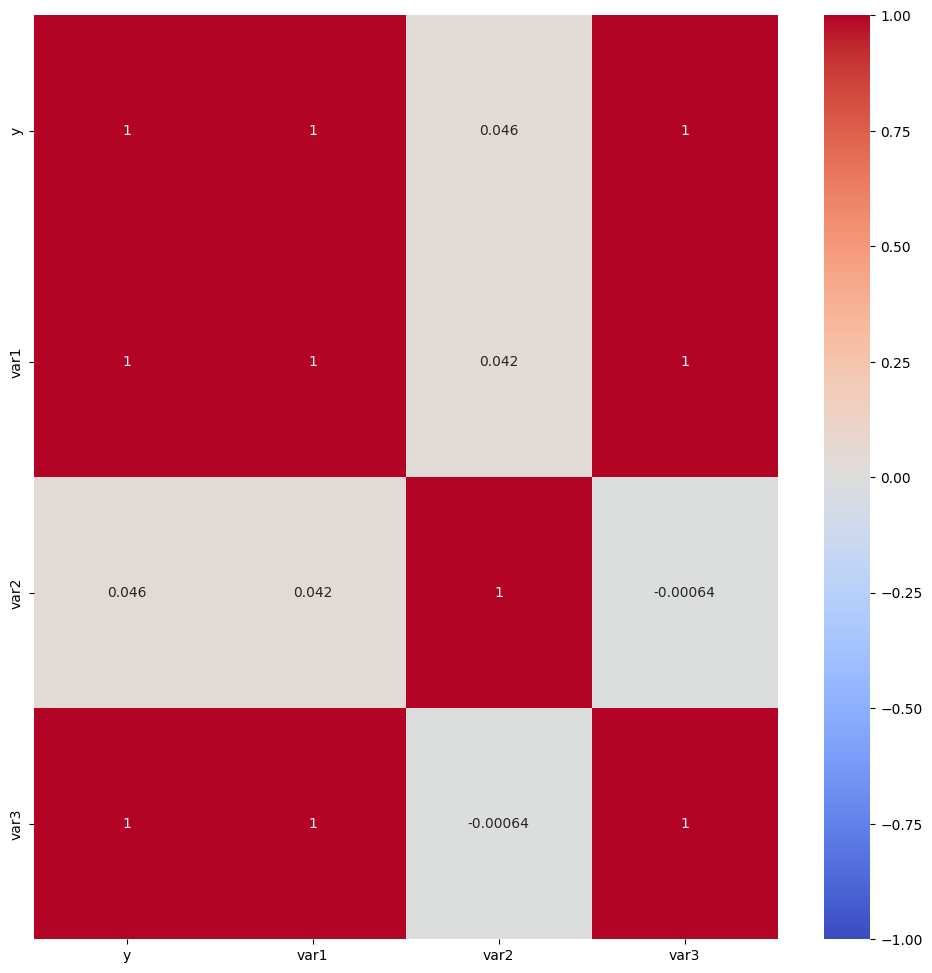

In [165]:
corr_noisy = df_noisy.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_noisy, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

## Plot the original vs noisy data to see the differences

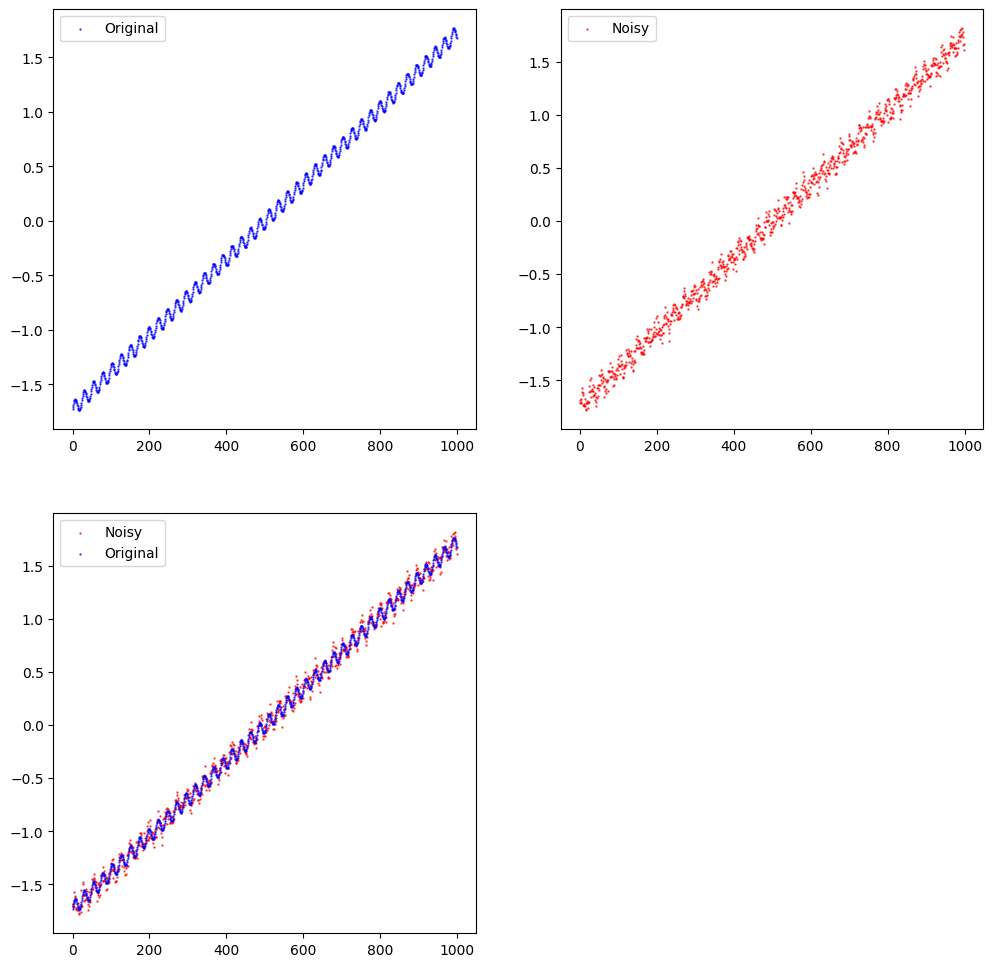

In [166]:
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.scatter(range(len(df_scaled['y'])), df_scaled['y'], alpha=0.7, c='b', label='Original', s=0.5)
plt.legend()
plt.subplot(2, 2, 2)
plt.scatter(range(len(df_noisy['y'])), df_noisy['y'], alpha=0.7, c='r', label='Noisy', s=0.5)
plt.legend()
plt.subplot(2, 2, 3)
plt.scatter(range(len(df_noisy['y'])), df_noisy['y'], alpha=0.7, c='r', label='Noisy', s=0.5)
plt.scatter(range(len(df_scaled['y'])), df_scaled['y'], alpha=0.7, c='b', label='Original', s=0.5)
plt.legend()

# Noisy XAI Benchmarck

In [167]:
X_train, X_test, y_train, y_test = train_test_split(
    df_noisy.drop(columns=['y'], inplace=False).values, df_noisy['y'].values, test_size=0.2, shuffle=False
)

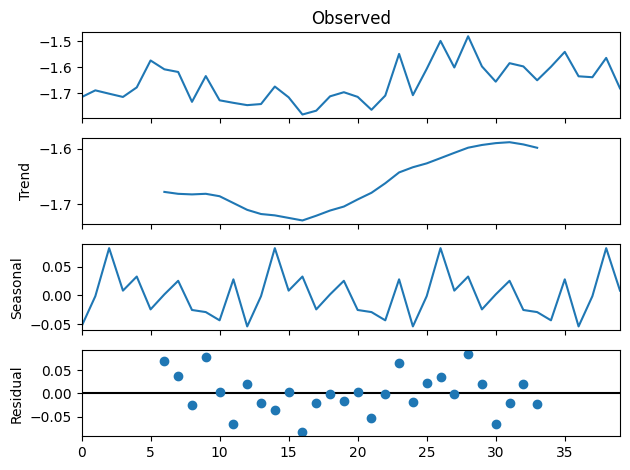

In [168]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(y_train[:40], model="additive", period=12)
decomposition.plot()
plt.show()

In [169]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {},#"dual": 'auto', "max_iter": 1000},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
    'arima': {}
    # {
    #     'order': (1, 1, 0),
    #     'seasonal_order': (4, 0, 5, 12)
    # }
}
xai_benchmark = XAIBenchmark(is_ts = True, model_params = model_params)

In [170]:
xai_benchmark.fit(X_train, y_train)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [171]:
predictions, metrics = xai_benchmark.predict(X_test, y_test, get_metrics=True)
metrics

Calculating metrics for ridge model...
Calculating metrics for pls model...
Calculating metrics for decision_tree model...
Calculating metrics for svm model...
Calculating metrics for knn model...
Calculating metrics for arima model...


{'ridge': {'mse': 0.003380654472838129,
  'rmse': 0.0581433957800723,
  'mae': 0.047276304348151985,
  'mape': 0.035184850419453344,
  'R2': 0.9265197946549586},
 'pls': {'mse': 0.0034196120229159767,
  'rmse': 0.05847744884069394,
  'mae': 0.04745319015518309,
  'mape': 0.03536855002679161,
  'R2': 0.9256730329398943},
 'decision_tree': {'mse': 0.22352228197042623,
  'rmse': 0.4727814314991931,
  'mae': 0.42526849798370064,
  'mape': 0.2909387068386179,
  'R2': -3.8583679019377852},
 'svm': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None},
 'knn': {'mse': 0.19531153073266125,
  'rmse': 0.4419406416394189,
  'mae': 0.39565745514679324,
  'mape': 0.2706729718416072,
  'R2': -3.245193201434133},
 'arima': {'mse': None, 'rmse': None, 'mae': None, 'mape': None, 'R2': None}}

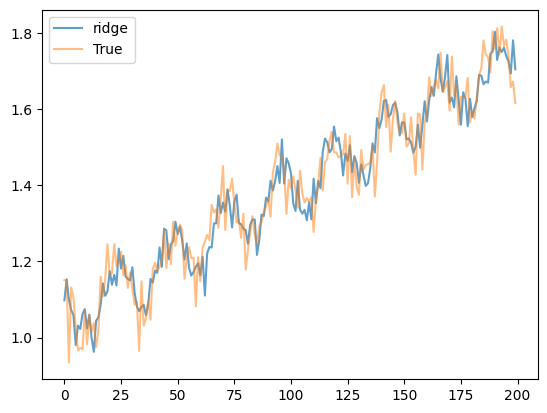

In [172]:
plt.plot(predictions['ridge'], label='ridge', alpha=0.7)
plt.plot(y_test, label='True', alpha=0.5)
plt.legend()

## Stablish the window size

In [173]:
window_size = 24

# Train a Model with the Original data

In [174]:
# Dividir en conjunto de entrenamiento y prueba
# X_train, X_test, y_train, y_test = train_test_split(df_scaled[df_scaled.columns[:-1]].copy(), df_scaled[df_scaled.columns[-1]].copy(), test_size=0.2, shuffle=False)
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [175]:
# train_dataset = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=1)
# val_dataset = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=1)
# test_dataset = SlidingWindowDataset(X_test, y_test, window_size=window_size, future=1)

In [176]:
# input_size = X_train.shape[-1] # Número de variables de entrada
# hidden_size = 128  # Número de neuronas en la capa oculta
# output_size = 1  # Predicción de una variable

# # Crear el modelo
# model_orig = LSTMModel(input_size, hidden_size, output_size).to(device)

# # Definir la función de pérdida y el optimizador
# criterion = nn.MSELoss()  # Error cuadrático medio
# optimizer = optim.Adam(model_orig.parameters(), lr=0.001)

In [177]:
# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
# val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
# test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [178]:
# trainer_orig = Trainer(
#     model = model_orig,
#     train_generator = train_dataloader,
#     val_generator = val_dataloader,
#     device = device,
#     criterion = criterion,
#     optimizer = optimizer,
#     epoch_scheduler = None,
#     batch_scheduler = None,
#     patience = 10,
#     epochs = 500,
#     checkpoints_path = os.path.join(CHECKPOINT_PATH, 'WTH', f'dense_sigma{0}'),
# )

In [179]:
# Train the model

# Comment if you want to load the model
# best_model, train_losses, val_losses, train_loss_when_best_val_loss, best_val_loss = trainer_orig.fit(verbose=True)

In [180]:
# predictions_test = trainer_orig.eval_dataloader(test_dataloader)
# predictions_flattened = np.array([y.cpu().detach().numpy() for x in predictions_test for y in x])
# len(predictions_flattened)

In [181]:
# predictions_train = trainer_orig.eval_dataloader(train_dataloader)
# predictions_train_flattened = np.array([y.cpu().detach().numpy() for x in predictions_train for y in x])
# len(predictions_train_flattened)

In [182]:
# predictions_val = trainer_orig.eval_dataloader(val_dataloader)
# predictions_val_flattened = np.array([y.cpu().detach().numpy() for x in predictions_val for y in x])
# len(predictions_val_flattened)

In [183]:
# test_to_compare = y_test.values[window_size:]

In [184]:
# mse_orig = mean_squared_error(test_to_compare, predictions_flattened)
# rmse_orig = np.sqrt(mse_orig)
# mae_orig = mean_absolute_error(test_to_compare, predictions_flattened)
# r2_orig = r2_score(test_to_compare, predictions_flattened)

In [185]:
# print(f'MSE: {mse_orig:.4f}')
# print(f'RMSE: {rmse_orig:.4f}')
# print(f'MAE: {mae_orig:.4f}')
# print(f'R2: {r2_orig:.4f}')

# Train a Model with Noisy data

In [186]:
df_noisy.columns

Index(['y', 'var1', 'var2', 'var3'], dtype='object')

In [209]:
# Dividir en conjunto de entrenamiento y prueba
input_variables = list(set(df_noisy.columns) - set(['y']))
input_variables_lstm = df_noisy.columns
X_train, X_test, y_train, y_test = train_test_split(df_noisy[input_variables_lstm], df_noisy[['y']], test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [210]:
train_dataset = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=1)
val_dataset = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=1)
test_dataset = SlidingWindowDataset(X_test, y_test, window_size=window_size, future=1)

# train_dataset = TensorDataset(X_train.values, y_train.values)
# val_dataset = TensorDataset(X_val.values, y_val.values)
# test_dataset = TensorDataset(X_test.values, y_test.values)

In [223]:
input_size = X_train.shape[-1] # Número de variables de entrada
input_size_lstm = len(input_variables_lstm)  # Número de variables de entrada
hidden_size = 128  # Número de neuronas en la capa oculta
output_size = 1  # Predicción de una variable

# model_noisy = GridFullyDenseNN(
#     n_layers=10,
#     hidden_layers=[
#         (input_size, 64),
#         (64, 128),
#         (128, 512),
#         (512, 1024),
#         (1024, 2048),
#         (2048, 2048),
#         (2048, 1024),
#         (1024, 512),
#         (512, 128),
#         (128, 1)
#     ],
#     dropout_layers=[0.2]*10,
#     activation_func_layers=[nn.Tanh()]*9 + [nn.Identity()],
#     want_activation=[True]*10,
#     want_dropout=[False]*10,
#     want_linear=[True]*10,
# ).to(device)

# Crear el modelo
model_noisy = LSTMModel(input_size_lstm, hidden_size, output_size).to(device)

# Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Error cuadrático medio
optimizer = optim.Adam(model_noisy.parameters(), lr=0.001)

In [224]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [225]:
# Load checkpoint
# Comment if you want to train the model
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, 'WTH','dense_sigma0.1.pth')))

In [226]:
trainer_noisy = Trainer(
    model = model_noisy,
    train_generator = train_dataloader,
    val_generator = val_dataloader,
    device = device,
    criterion = criterion,
    optimizer = optimizer,
    epoch_scheduler = None,
    batch_scheduler = None,
    patience = 15,
    epochs = 500,
    checkpoints_path = os.path.join(CHECKPOINT_PATH, 'WTH', f'dense_sigma{0.5}'),
)

In [227]:
# Train the model
# Comment if you want to load the model
best_model, train_losses, val_losses, train_loss_when_best_val_loss, best_val_loss = trainer_noisy.fit(verbose=True)

Training is started!


Epochs loop:  18%|█▊        | 88/500 [00:12<00:59,  6.91epoch/s, Train loss: 0.0048]                   

Training stopped as validation loss did not improve for 15 epochs.


In [228]:
predictions_test = trainer_noisy.eval_dataloader(test_dataloader)
predictions_flattened = np.array([y for x in predictions_test for y in x])
len(predictions_flattened)

/home/jjavier98/miniconda3/envs/torch_env/lib/python3.9/site-packages/torch/nn/modules/rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1412.)
  result = _VF.lstm(


176

In [229]:
test_to_compare = y_test.values[window_size:]

In [230]:
mse_noisy = mean_squared_error(test_to_compare, predictions_flattened)
rmse_noisy = np.sqrt(mse_noisy)
mae_noisy = mean_absolute_error(test_to_compare, predictions_flattened)
r2_noisy = r2_score(test_to_compare, predictions_flattened)

In [231]:
print(f'MSE: {mse_noisy:.4f}')
print(f'RMSE: {rmse_noisy:.4f}')
print(f'MAE: {mae_noisy:.4f}')
print(f'R2: {r2_noisy:.4f}')

MSE: 0.0107
RMSE: 0.1036
MAE: 0.0859
R2: 0.7089


# Perform the noise reduction algorithm

In [235]:
x_cols = input_variables_lstm
x_sliding = df_noisy[x_cols].copy()#.reset_index(drop=True)
y_sliding = df_noisy[['y']].copy()#.reset_index(drop=True)
df_to_denoise = SlidingWindowDataset(x_sliding, y_sliding, window_size=window_size, future=1)
# df_to_denoise = DataLoader(df_to_denoise, batch_size=len(df_to_denoise), shuffle=False)

In [236]:
model_noisy.train()
dlnr = DLNoiseReduction(model=model_noisy, criterion=criterion, is_ts=True)
dlnr.fit(df_to_denoise)

In [239]:
X_denoised, y_denoised, _, _ = dlnr.transform(
    nrr=0.05,
    nr_threshold=0.005,
    max_epochs=1000,
    plot_progress=False,
    denoise_y=False,
    save_gradients=False,
)

100%|██████████| 976000/976000 [1:02:39<00:00, 259.64it/s]

Max epochs reached: 1.0


In [247]:
X_denoised_df = pd.DataFrame(X_denoised, columns=x_cols)

## Plot the Original VS Noisy VS Denoised Data

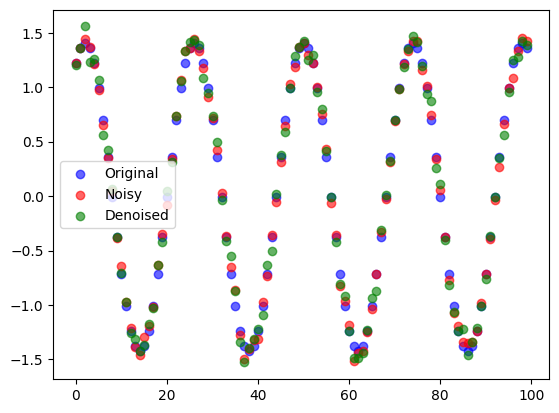

In [250]:
plt.scatter(range(len(df_scaled[df_scaled.columns[2]][100:200])), df_scaled[df_scaled.columns[2]][100:200], alpha=0.6, c='b', label='Original')
plt.scatter(range(len(df_noisy[df_noisy.columns[2]][100:200])), df_noisy[df_noisy.columns[2]][100:200], alpha=0.6, c='r', label='Noisy')
plt.scatter(range(len(X_denoised_df[X_denoised_df.columns[2]][100:200])), X_denoised_df[X_denoised_df.columns[2]][100:200], alpha=0.6, c='g', label='Denoised')
plt.legend()

## Show the denoised data correlation matrix

<Axes: >

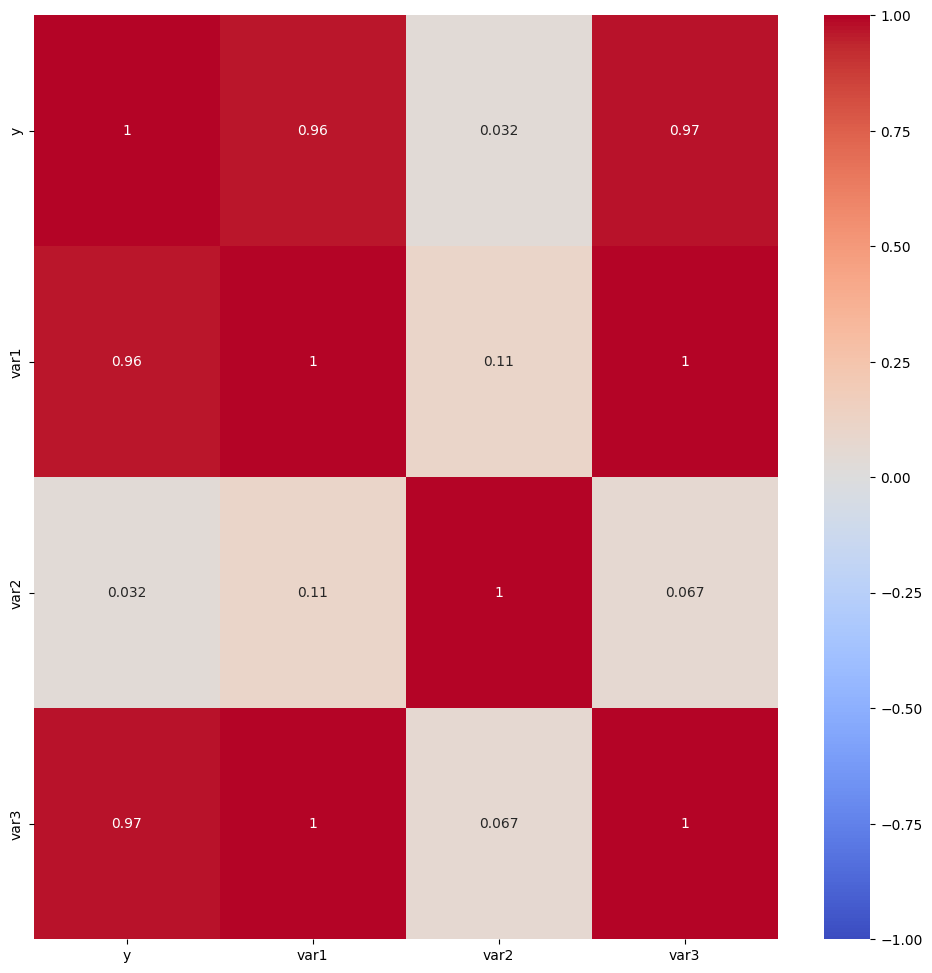

In [251]:
# total_denoise = pd.concat([X_denoised_df, pd.DataFrame(y_denoised, columns=['Y'])], axis=1)
corr_denoised = pd.DataFrame(X_denoised_df).corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_denoised, annot=True, cmap='coolwarm', vmin=-1, vmax=1)


## Print some metrics

- rmse(noisy, orig) > rmse(denoised, orig): el error entre las matrices de correlación de los datos ruidosos frente a los originales debe ser mayor al error entre las matrices de correlación de los datos filtrados y los originales.
- la correlación media de los datos filtrados debe ser mayor que la correlación media de los datos con ruido.

In [ ]:
np.sqrt(mean_squared_error(corr_noisy, corr_orig)) > np.sqrt(mean_squared_error(corr_denoised, corr_orig))

In [ ]:
np.mean(corr_denoised) > np.mean(corr_noisy)

## Show the difference between the correlation matrix of the denoised data VS noisy data

<Axes: >

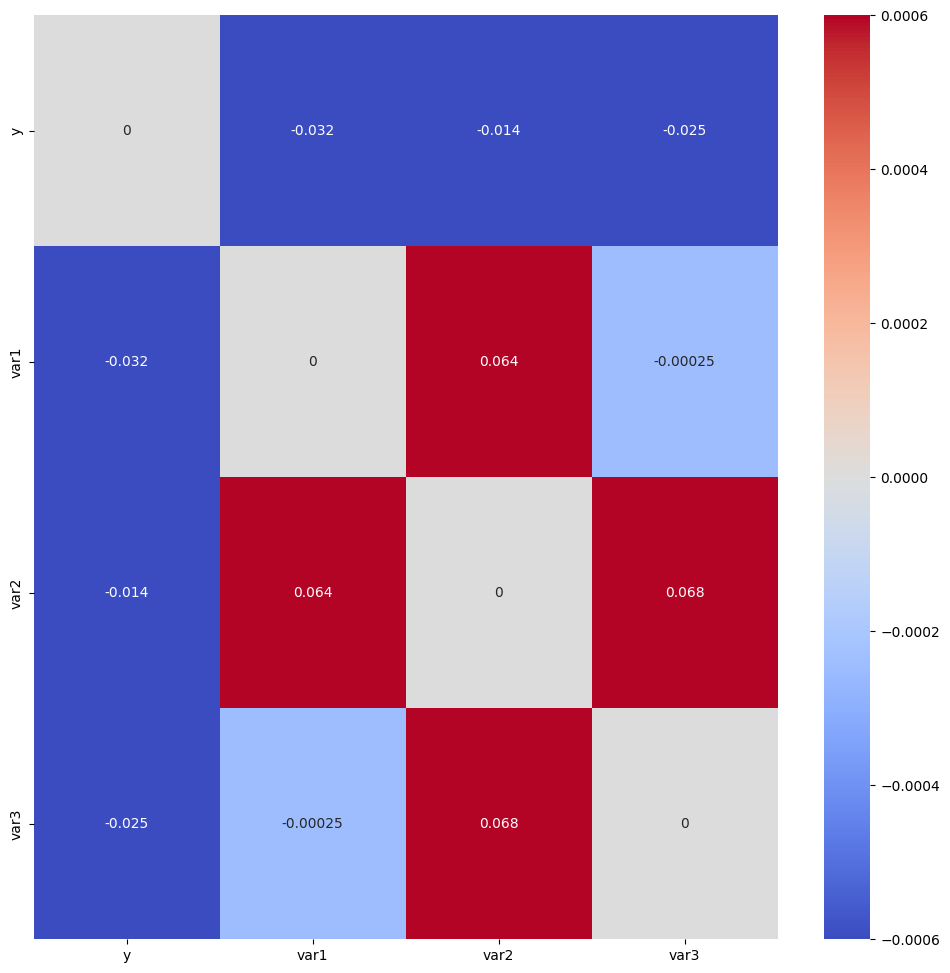

In [252]:
diff_corr = corr_denoised - corr_noisy
plt.figure(figsize=(12, 12))
sns.heatmap(diff_corr, annot=True, cmap='coolwarm', vmin=-0.0006, vmax=0.0006)

# Train a Model with the Denoised data

In [253]:
# Dividir en conjunto de entrenamiento y prueba
X_train_denoised, X_test_denoised, y_train_denoised, y_test_denoised = train_test_split(X_denoised_df, X_denoised_df[['y']], test_size=0.2, shuffle=False)
X_train_denoised, X_val_denoised, y_train_denoised, y_val_denoised = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [254]:
train_dataset = SlidingWindowDataset(X_train_denoised, y_train_denoised, window_size=window_size, future=1)
val_dataset = SlidingWindowDataset(X_val_denoised, y_val_denoised, window_size=window_size, future=1)
test_dataset = SlidingWindowDataset(X_test_denoised, y_test_denoised, window_size=window_size, future=1)

In [ ]:
input_size = X_train.shape[-1] # Número de variables de entrada
hidden_size = 128  # Número de neuronas en la capa oculta
output_size = 1  # Predicción de una variable

# Crear el modelo
model_denoised = LSTMModel(input_size, hidden_size, output_size).to(device)

# Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Error cuadrático medio
optimizer = optim.Adam(model_denoised.parameters(), lr=0.001)

In [255]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Load checkpoint
# Comment if you want to train the model
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, 'WTH','dense_sigma0.1.pth')))

In [ ]:
trainer_denoised = Trainer(
    model = model_denoised,
    train_generator = train_dataloader,
    val_generator = val_dataloader,
    device = device,
    criterion = criterion,
    optimizer = optimizer,
    epoch_scheduler = None,
    batch_scheduler = None,
    patience = 10,
    epochs = 500,
    checkpoints_path = os.path.join(CHECKPOINT_PATH, 'syntetic_ts', f'lstm_sigma{sigma}'),
)

In [ ]:
# Train the model
# Comment if you want to load the model
best_model, train_losses, val_losses, train_loss_when_best_val_loss, best_val_loss = trainer_denoised.fit(verbose=True)

In [ ]:
predictions_test = trainer_denoised.eval_dataloader(test_dataloader)
predictions_flattened = np.array([y.cpu().detach().numpy() for x in predictions_test for y in x])
len(predictions_flattened)

In [ ]:
test_to_compare = y_test.values[window_size:]

In [ ]:
mse_denoised = mean_squared_error(test_to_compare, predictions_flattened)
rmse_denoised = np.sqrt(mse_denoised)
mae_denoised = mean_absolute_error(test_to_compare, predictions_flattened)
r2_denoised = r2_score(test_to_compare, predictions_flattened)

In [ ]:
print(f'MSE: {mse_denoised:.4f}')
print(f'RMSE: {rmse_denoised:.4f}')
print(f'MAE: {mae_denoised:.4f}')
print(f'R2: {r2_denoised:.4f}')

# Denoised XAI Benchmarck

In [256]:
y_train_denoised = trainer_denoised.eval_dataloader(train_dataloader)
y_train_denoised = np.array([y.cpu().detach().numpy() for x in y_train_denoised for y in x])
len(y_train_denoised)

NameError: name 'trainer_denoised' is not defined

In [ ]:
X_train_denoised.iloc[window_size:]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_denoised.iloc[window_size:], y_train_denoised, test_size=0.2, shuffle=False
)

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(y_train[:40], model="additive", period=12)
decomposition.plot()
plt.show()

In [ ]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {"dual": 'auto', "max_iter": 1000},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
    'arima': {
        'order': (1, 1, 0),
        'seasonal_order': (4, 0, 5, 12)
    }
}
xai_benchmark = XAI_benchmark(is_ts = True, model_params = model_params)

In [ ]:
xai_benchmark.fit(X_train, y_train)

In [ ]:
predictions, metrics = xai_benchmark.predict(X_test, y_test, get_metrics=True)
metrics

In [ ]:
plt.plot(predictions['arima'], label='ARIMA', alpha=0.7)
plt.plot(y_test, label='True', alpha=0.5)
plt.legend()